In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))


import cococo.layouts as layouts
import cococo.utils_routing as utils
import cococo.circuit_construction as circuit_construction
import cococo.internal_testing as internal_testing
import plotting

## Example for Router with Movable Qubits

### Choose Layout

In [2]:
layout_type = "row"
m = 4
n = 4
factories = []
remove_edges = False
g, data_qubit_locs, factory_ring = layouts.gen_layout_scalable(layout_type, m, n, factories, remove_edges)
layout = {i: j for i,j in enumerate(data_qubit_locs)} #mapping
t=2 #mock because we have only cnots here in the example

/mnt/c/Users/faceb/OneDrive/Desktop/TUM_CSE/master_thesis/Code/cococo_hs/scripts/plotting.py:184: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


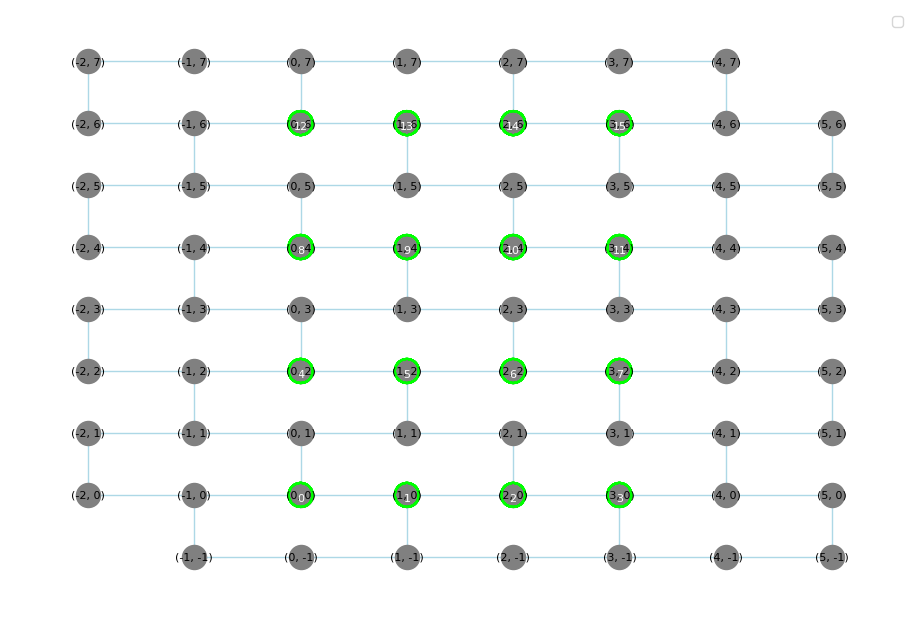

In [3]:
plotting.plot_lattice_paths(g, {}, {}, layout, factories, size = (9,6))

### Choose Circuit

In [4]:
q = len(data_qubit_locs)
j = 8
num_gates = q*2
dag, pairs = circuit_construction.create_random_sequential_circuit_dag(j, q, num_gates, )
print(pairs)

[(8, 13), (15, 2), (9, 10), (0, 3), (1, 4), (6, 5), (11, 12), (7, 14), (8, 1), (3, 2), (9, 11), (0, 14), (4, 6), (15, 5), (12, 10), (13, 7), (7, 1), (3, 2), (11, 9), (12, 14), (8, 6), (15, 4), (10, 0), (13, 5), (14, 7), (2, 13), (9, 6), (12, 3), (11, 8), (4, 15), (0, 1), (5, 10)]


### Run Standard Router with Standard Layout

In [5]:
terminal_pairs = layouts.translate_layout_circuit(pairs, layout) #let's stick to the simple layout

In [6]:
router = utils.BasicRouter(g, data_qubit_locs, factories, valid_path = "cc", t=t, metric = "exact", use_dag = True)
layers = router.split_layer_terminal_pairs(terminal_pairs)
vdp_layers, _ = router.find_total_vdp_layers_dyn(layers, data_qubit_locs, router.factory_times, layout, testing = True)
print("Len of schedule without teleportation: ", len(vdp_layers))

2026-05-13 10:26:19,709 [INFO] root: stim test succeeded for standard routing (:
2026-05-13 10:26:19,710 [INFO] root: no duplicates found in standard routing (:
2026-05-13 10:26:19,711 [INFO] root: paths do not occupy logical pos (:
2026-05-13 10:26:19,714 [INFO] root: Reset times make sense, all good(:
Len of schedule without teleportation:  12


### Run Movable Qubits Router with Standard Initial Layout

In [7]:
router = utils.TeleportationRouter(g, data_qubit_locs, factories, valid_path="cc", t=t, metric="exact", use_dag = True, seed = 49218)
layers = router.split_layer_terminal_pairs(terminal_pairs)

max_iters = 100
T_start = 100.0
T_end = 0.1
alpha = 0.95
t=4 #mock value for cnot circuit
radius = 10
k_lookahead = 5
metric = "exact"

steiner_init_type = "full_random"
jump_harvesting = True
stimtest = True

reduce_steiner = True
idle_move_type = "later"

schedule, _ = router.optimize_layers(        
        terminal_pairs,
        layout,
        max_iters,
        T_start,
        T_end,
        alpha,
        radius = radius,
        k_lookahead = k_lookahead,
        steiner_init_type = steiner_init_type,
        jump_harvesting = jump_harvesting,
        reduce_teleport = reduce_steiner,
        idle_move_type = idle_move_type,
        reduce_init_steiner = False,
        stimtest = True,
        include_steiner_teleport = True,
        include_idle_teleport = False,)

2026-05-13 10:26:19,765 [INFO] root: Iteration 0: |vdp_dict|=4, pushing |terminal_pairs_remainder|=4, remaining |layers|=4
2026-05-13 10:26:34,100 [INFO] root: No Steiner improvement possible in this layer.
2026-05-13 10:26:34,102 [INFO] root: Final Temperature T = 5.920529e-01
best_steiner_init:  None
best_idle_init:  None
2026-05-13 10:26:34,176 [INFO] root: Iteration 1: |vdp_dict|=2, pushing |terminal_pairs_remainder|=3, remaining |layers|=4
2026-05-13 10:26:46,083 [INFO] root: No Steiner improvement possible in this layer.
2026-05-13 10:26:46,084 [INFO] root: Final Temperature T = 5.920529e-01
best_steiner_init:  None
best_idle_init:  None
2026-05-13 10:26:46,135 [INFO] root: Iteration 2: |vdp_dict|=4, pushing |terminal_pairs_remainder|=2, remaining |layers|=4
2026-05-13 10:26:52,956 [INFO] root: Steiner found for this layer.
2026-05-13 10:26:52,957 [INFO] root: Final Temperature T = 5.920529e-01
best_steiner_init:  {((0, 2), (2, 2), (0, 3)): ([(0, 2), (0, 3), (1, 3), (2, 3), (2, 2

In [8]:
print("Len of schedule with teleport router: ", len(schedule))

Len of schedule with teleport router:  11


In [9]:
print("Reduction Delta: ", len(vdp_layers) - len(schedule))

Reduction Delta:  1


Step 1: Move Type - None, Idle Move - None
vdp dict dict_keys([((0, 4), (1, 6)), ((0, 0), (3, 0)), ((1, 0), (0, 2)), ((1, 4), (2, 4))])


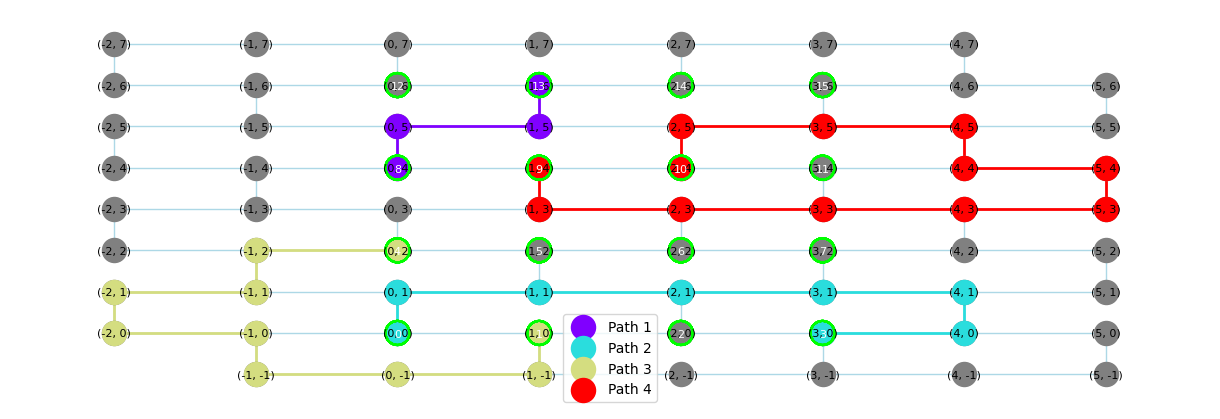

Step 2: Move Type - None, Idle Move - None
vdp dict dict_keys([((3, 4), (0, 6)), ((2, 2), (1, 2))])


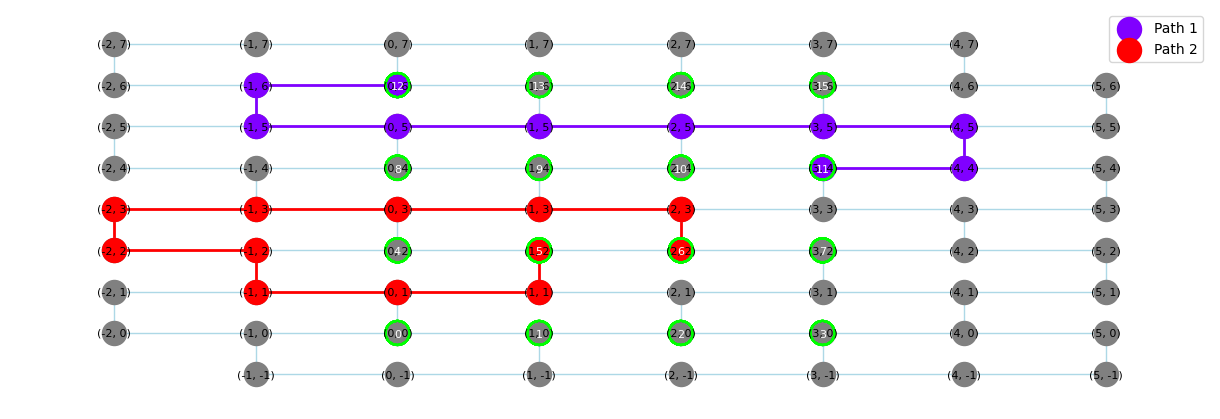

Step 3: Move Type - {((0, 2), (2, 2), (0, 3)): 'target'}, Idle Move - None
vdp dict dict_keys([((0, 2), (2, 2)), ((0, 6), (2, 4)), ((0, 4), (1, 0)), ((3, 2), (2, 6))])


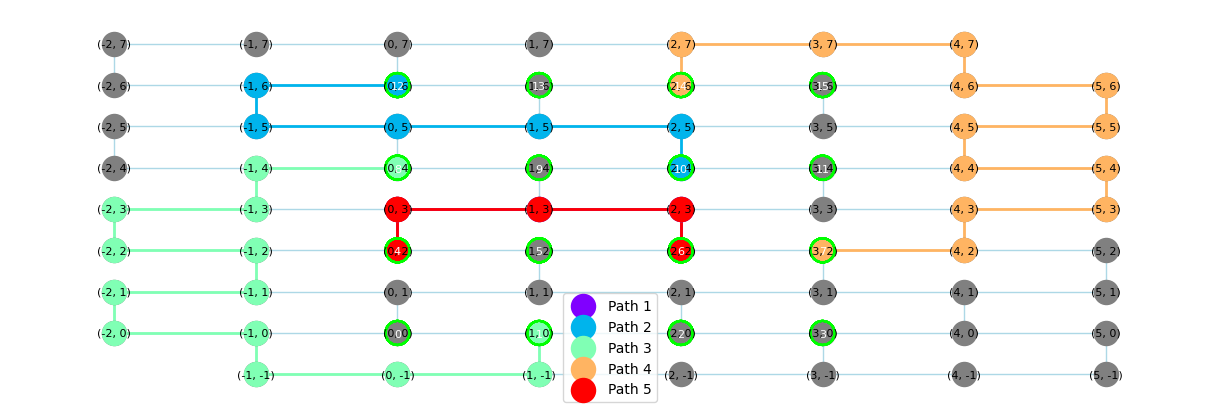

Step 4: Move Type - None, Idle Move - None
vdp dict dict_keys([((0, 4), (0, 3)), ((1, 4), (3, 4)), ((1, 6), (3, 2))])


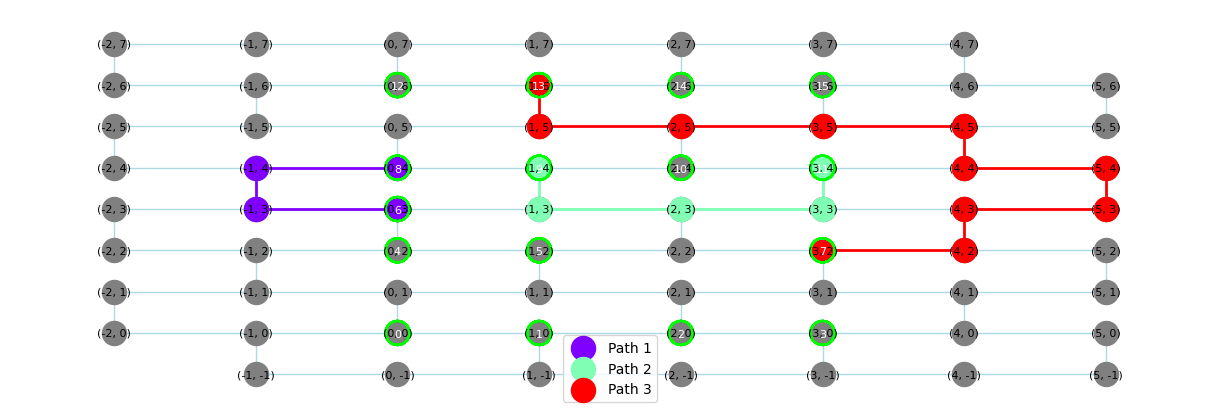

Step 5: Move Type - None, Idle Move - None
vdp dict dict_keys([((3, 4), (1, 4)), ((3, 2), (1, 0)), ((3, 6), (2, 0))])


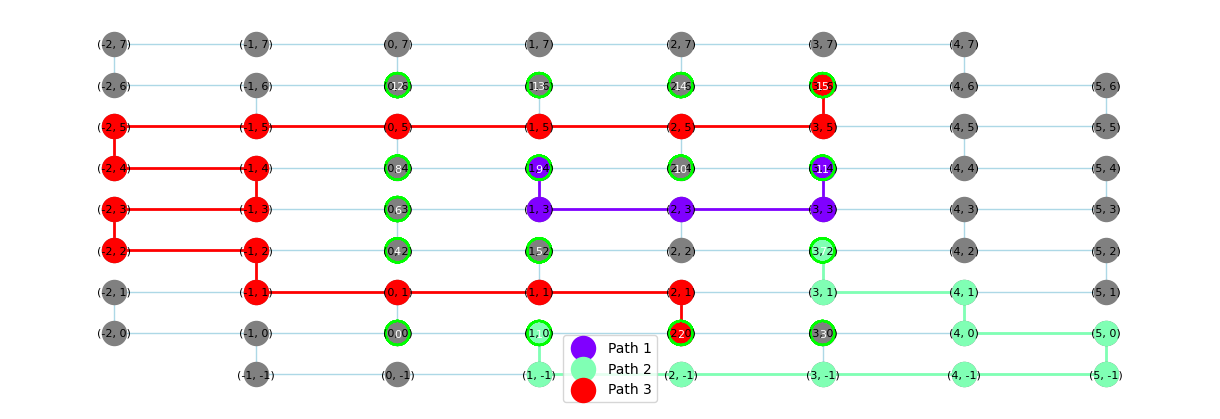

Step 6: Move Type - None, Idle Move - None
vdp dict dict_keys([((1, 4), (0, 3)), ((3, 0), (2, 0)), ((3, 4), (0, 4)), ((0, 0), (2, 6))])


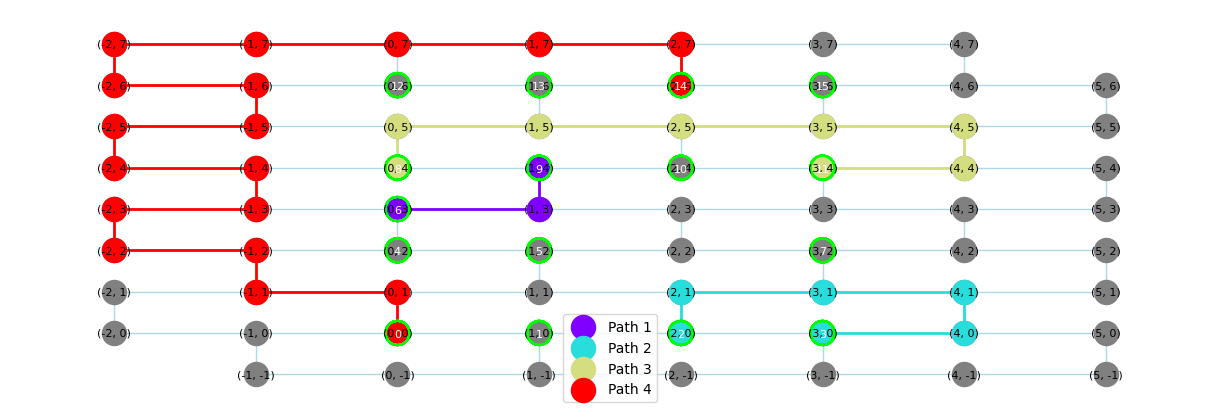

Step 7: Move Type - None, Idle Move - None
vdp dict dict_keys([((0, 6), (2, 6)), ((3, 0), (2, 0)), ((3, 6), (1, 2)), ((2, 4), (0, 0))])


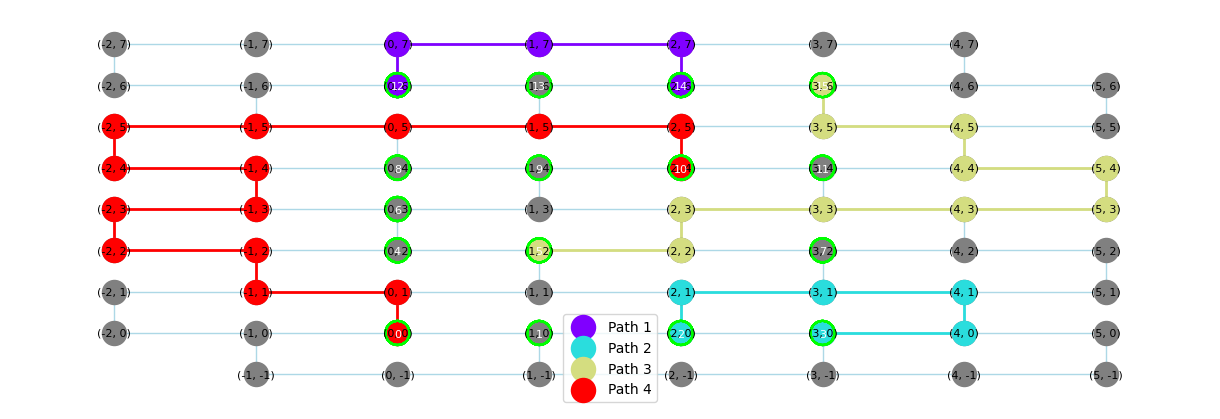

Step 8: Move Type - None, Idle Move - None
vdp dict dict_keys([((0, 0), (1, 0)), ((1, 6), (1, 2)), ((0, 6), (3, 0))])


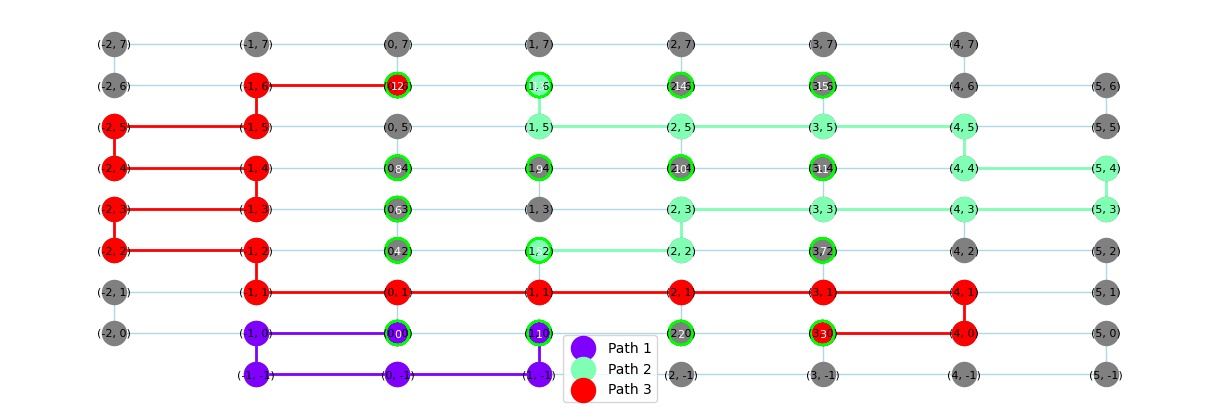

Step 9: Move Type - None, Idle Move - None
vdp dict dict_keys([((1, 2), (2, 4)), ((2, 0), (1, 6))])


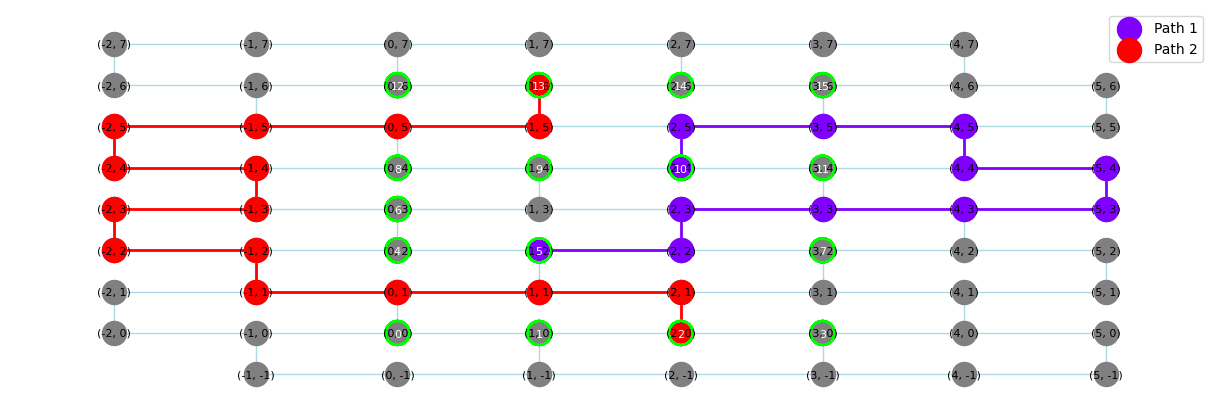

Step 10: Move Type - None, Idle Move - None
vdp dict dict_keys([((2, 6), (3, 2)), ((3, 6), (0, 2))])


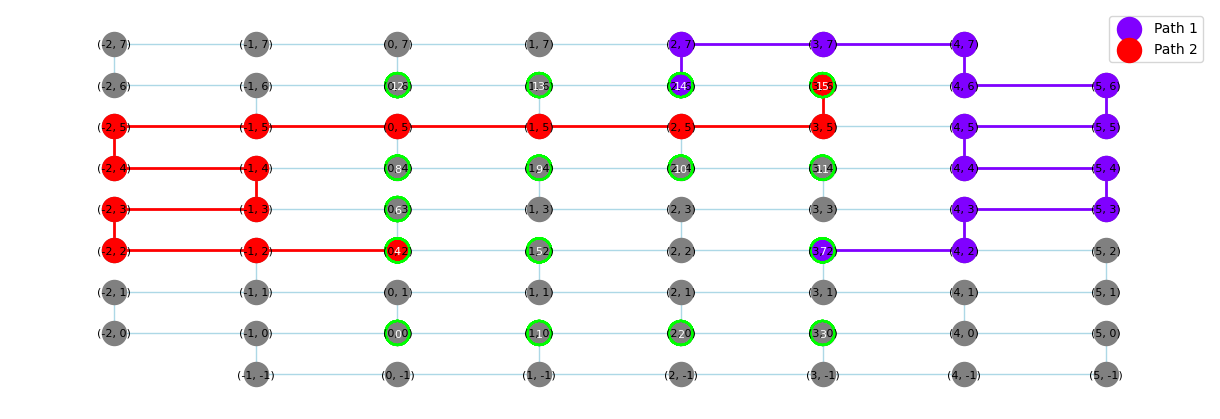

Step 11: Move Type - None, Idle Move - None
vdp dict dict_keys([((0, 2), (3, 6))])


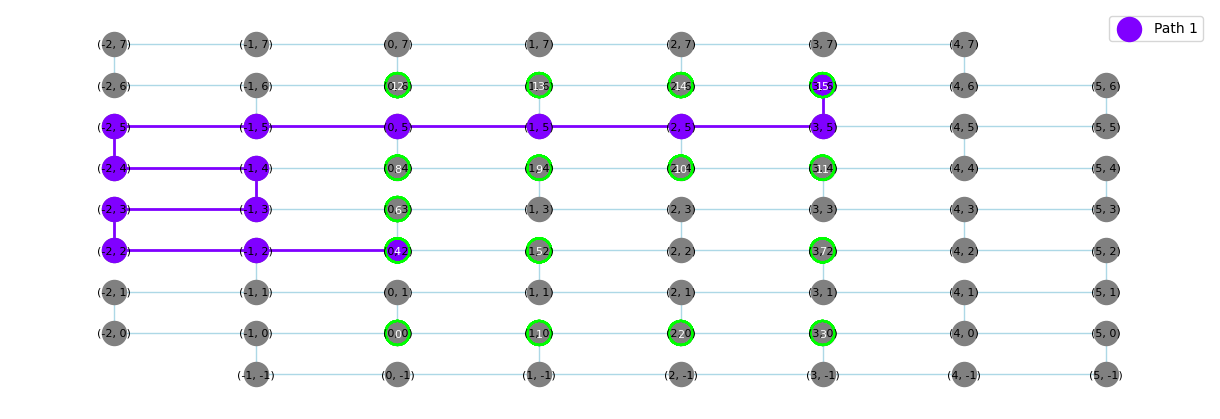

In [12]:
plotting.plot_schedule(g, schedule[:11], factories, size=(12, 4))

In [11]:
from IPython.display import HTML
from cococo.animation_routing_html import make_clean_routing_html_animation

anim = make_clean_routing_html_animation(
    g,
    schedule,
    initial_layout=layout,
    factories=factories,
    figsize=(18, 8),
    interval=900,
    save_path="routing_animation.html",
)

HTML(anim.to_jshtml())

2026-05-13 10:26:54,909 [INFO] matplotlib.animation: Animation.save using <class 'matplotlib.animation.HTMLWriter'>
